In [33]:
import duckdb
import pandas as pd
import plotly.express as px


# 1. Verbindung zu DuckDB herstellen (In-Memory ist für Abfragen auf Parquet super schnell)
con = duckdb.connect(database=':memory:')

# 2. Den Pfad zu deinen Parquet-Dateien definieren (Passe den Pfad an dein Cluster an)
# Der Stern ** bedeutet: Suche in allen Unterordnern nach Parquet-Dateien
PARQUET_PATH = "/mnt/shared_data/finflow/obis_raw/*/*/*.parquet"

In [34]:
query_create_view = f"""
CREATE VIEW obis_clean AS 
SELECT DISTINCT ON (id) * FROM read_parquet('{PARQUET_PATH}', filename=true);
"""
con.execute(query_create_view)

In [35]:
query_create_view = f"""
CREATE VIEW obis_unclean AS 
SELECT DISTINCT ON (id) * FROM read_parquet('{PARQUET_PATH}', filename=true);
"""
con.execute(query_create_view)

In [36]:
query = f"""
SELECT 
    COUNT(id) AS total_rows,
    COUNT(DISTINCT id) AS unique_records,
    COUNT(id) - COUNT(DISTINCT id) AS duplicate_count
FROM obis_unclean;
"""
con.execute(query).df()

,total_rows,unique_records,duplicate_count
0,3911545,3911545,0


In [37]:
query_time = """
SELECT 
    MIN(eventDate) as start_datum, 
    MAX(eventDate) as end_datum
FROM obis_clean
WHERE eventDate IS NOT NULL;
"""
df_time = con.execute(query_time).df()
print(df_time)

                start_datum                 end_datum
0 2000-01-01 00:00:00+00:00 2026-01-09 18:47:43+00:00


/tmp/ipykernel_14213/3105696164.py:29: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



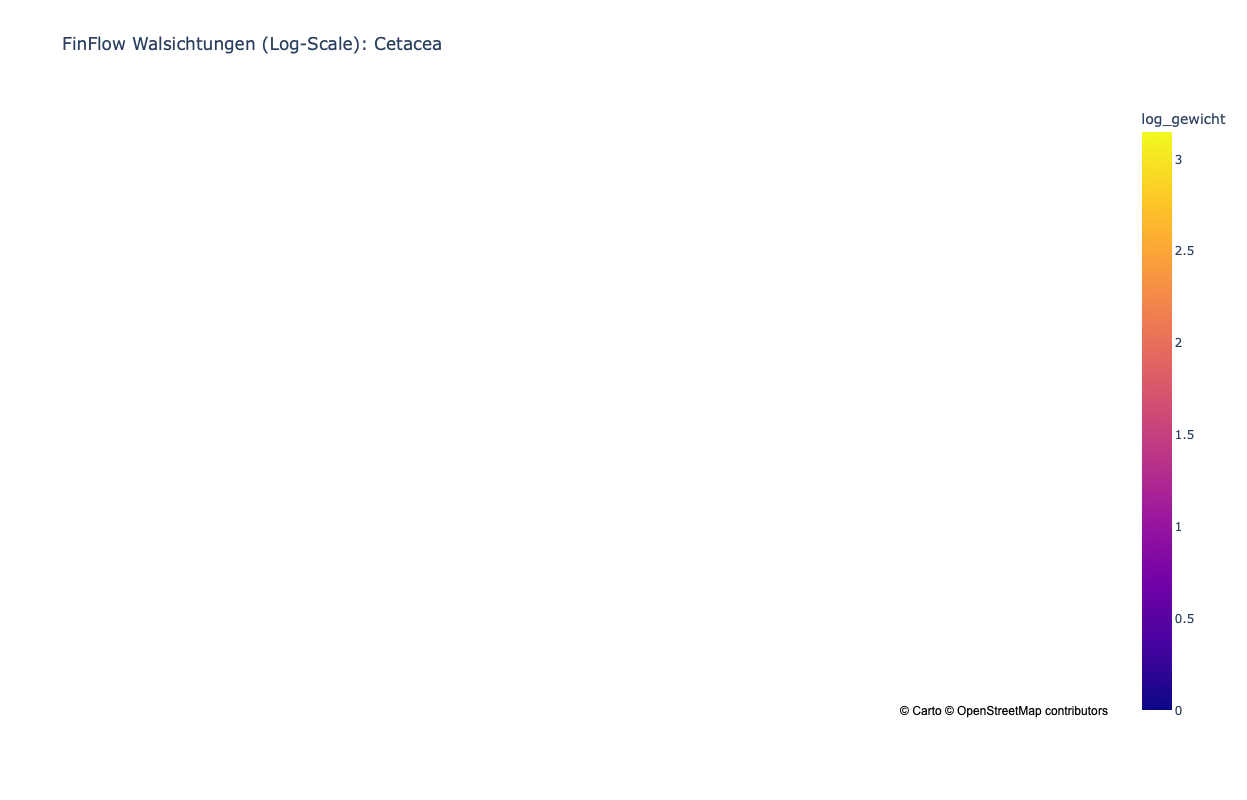

In [49]:
# 1. Deine Filter-Parameter
kategorie = "Cetacea"      # Optionen: Cetacea, Phocidae, Cheloniidae
start_datum = "2024-01-01"
end_datum = "2024-12-31"

# Wir greifen gezielt nur auf den Unterordner dieser Kategorie zu!
PARQUET_PATH = f"/mnt/shared_data/finflow/obis_raw/{kategorie}/*/*.parquet"

# DuckDB Abfrage mit LOG10 für die Farbskalierung
query = f"""
SELECT 
    ROUND(decimalLongitude, 1) AS lon,
    ROUND(decimalLatitude, 1) AS lat,
    COUNT(*) as echte_anzahl,
    LOG10(COUNT(*)) as log_gewicht
FROM read_parquet('{PARQUET_PATH}')
WHERE eventDate >= '{start_datum}' 
  AND eventDate <= '{end_datum}'
  AND decimalLongitude IS NOT NULL 
  AND decimalLatitude IS NOT NULL
  AND (decimalLongitude != 0 OR decimalLatitude != 0)
GROUP BY lon, lat
"""

con = duckdb.connect(database=':memory:')
df_map = con.execute(query).df()

# 3. Interaktive Scatter-Karte (viel schärfer für Bewegungen/Routen!)
fig = px.scatter_mapbox(
    df_map, 
    lat='lat', 
    lon='lon', 
    color='log_gewicht',          # Farbe basiert auf dem Logarithmus
    size='log_gewicht',           # Größe der Punkte basiert auch auf dem Logarithmus
    hover_data=['echte_anzahl'],  # Wenn du mit der Maus drüberfährst, zeigt er die echte Zahl!
    center=dict(lat=20, lon=0), 
    zoom=1.5,
    mapbox_style="carto-darkmatter",
    title=f"FinFlow Walsichtungen (Log-Scale): {kategorie}",
    color_continuous_scale="Plasma", # Plasma oder Turbo eignen sich hier extrem gut
    height=800
)

# Zeigt die Karte direkt im Notebook an
fig.show(config={'scrollZoom': True})

# Optional: Als interaktive HTML-Datei speichern, um sie anderen zu schicken!
# fig.write_html(f"heatmap_{kategorie.lower()}.html")

In [3]:
import duckdb
import plotly.express as px
import pandas as pd

# Pfad zu deinen OBIS-Daten
OBIS_PATH = "/mnt/shared_data/finflow/obis_raw/*/*/*.parquet" # Passe den Pfad ggf. an deine Ordnerstruktur an

print("Analysiere OBIS-Daten nach zusammenhaengenden Trajektorien (mit Schema-Union)...")

con = duckdb.connect(database=':memory:')

# union_by_name=True erlaubt es DuckDB, Dateien mit unterschiedlichen Spalten zu kombinieren
query = f"""
WITH TopTrackedAnimals AS (
    SELECT organismID, scientificName, COUNT(*) as pings
    FROM read_parquet('{OBIS_PATH}', union_by_name=True)
    WHERE organismID IS NOT NULL 
      AND organismID != ''
      AND decimalLongitude IS NOT NULL
      AND decimalLatitude IS NOT NULL
    GROUP BY organismID, scientificName
    HAVING COUNT(*) > 50
    ORDER BY pings DESC
    LIMIT 10
)
SELECT 
    o.organismID, 
    o.scientificName,
    o.decimalLongitude AS lon, 
    o.decimalLatitude AS lat, 
    o.eventDate AS timestamp
FROM read_parquet('{OBIS_PATH}', union_by_name=True) o
JOIN TopTrackedAnimals t ON o.organismID = t.organismID
ORDER BY o.organismID, o.eventDate
"""

try:
    df_tracks = con.execute(query).df()
    
    if len(df_tracks) > 0:
        print(f"Erfolg: {len(df_tracks)} Wegpunkte fuer {df_tracks['organismID'].nunique()} individuelle Tiere gefunden.")
        
        df_tracks['timestamp'] = pd.to_datetime(df_tracks['timestamp'], errors='coerce')
        df_tracks = df_tracks.sort_values(by=['organismID', 'timestamp'])

        fig = px.line_mapbox(
            df_tracks, 
            lat='lat', 
            lon='lon', 
            color='organismID',
            hover_name='scientificName',
            hover_data=['timestamp'],
            zoom=2,
            mapbox_style="carto-darkmatter",
            title="FinFlow: Rekonstruierte Tier-Trajektorien aus OBIS",
            height=800
        )

        fig.update_traces(line=dict(width=2), marker=dict(size=4))
        
        output_file = "finflow_obis_trajectories.html"
        fig.write_html(output_file)
        print(f"Karte generiert! Bitte oeffne '{output_file}' in deinem Browser.")
    else:
        print("In diesem Daten-Ausschnitt wurden keine Tiere mit einer durchgehenden organismID gefunden.")
        
except Exception as e:
    print(f"Fehler bei der Datenbankabfrage: {e}")

Analysiere OBIS-Daten nach zusammenhaengenden Trajektorien (mit Schema-Union)...
Erfolg: 153113 Wegpunkte fuer 10 individuelle Tiere gefunden.


/tmp/ipykernel_4802/2254865948.py:46: DeprecationWarning: *line_mapbox* is deprecated! Use *line_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.line_mapbox(


Karte generiert! Bitte oeffne 'finflow_obis_trajectories.html' in deinem Browser.
